<a href="https://colab.research.google.com/github/realRandomPL/ThucHanhDeepLearning/blob/main/ThucHanhDeepLearning_Buoi03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Input
from sklearn.preprocessing import MinMaxScaler

# 1. Tải bộ dữ liệu Fashion MNIST trực tiếp trên Colab (Theo tài liệu ANN trang 6)
fashion = tf.keras.datasets.fashion_mnist
(X_train_raw, y_train), (X_test_raw, y_test) = fashion.load_data()

# --- CHUẨN BỊ DỮ LIỆU CHO MÔ HÌNH 1: ANN ---
# Reshape từ dạng ảnh 3D thành vector phẳng 2D (Tài liệu ANN trang 6)
X_train_ann = X_train_raw.reshape(60000, 784)
X_test_ann = X_test_raw.reshape(10000, 784)

# Chuẩn hóa dữ liệu bằng MinMaxScaler về đoạn [0, 1] (Tài liệu ANN trang 6)
minmax = MinMaxScaler()
X_train_ann = minmax.fit_transform(X_train_ann)
X_test_ann = minmax.transform(X_test_ann)

# --- CHUẨN BỊ DỮ LIỆU CHO MÔ HÌNH 2: CNN ---
# Ép kiểu và chia 255 để chuẩn hóa ảnh về đoạn [0, 1] (Tài liệu CNN trang 6)
X_train_cnn = X_train_raw.astype("float32") / 255
X_test_cnn = X_test_raw.astype("float32") / 255

# Reshape về dạng ma trận 4D (Kích thước mẫu, Rộng, Cao, Kênh màu) (Tài liệu CNN trang 6)
X_train_cnn = X_train_cnn.reshape(X_train_cnn.shape[0], 28, 28, 1)
X_test_cnn = X_test_cnn.reshape(X_test_cnn.shape[0], 28, 28, 1)

# Cấu hình các hằng số mạng
num_classes = 10
input_shape_cnn = (28, 28, 1)

print("Đã chuẩn bị dữ liệu thành công!")
print("Kích thước dữ liệu ANN:", X_train_ann.shape)
print("Kích thước dữ liệu CNN:", X_train_cnn.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Đã chuẩn bị dữ liệu thành công!
Kích thước dữ liệu ANN: (60000, 784)
Kích thước dữ liệu CNN: (60000, 28, 28, 1)


In [2]:
print("====== BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH 1: ANN ======")

# Khởi tạo kiến trúc mạng ANN (Tài liệu ANN trang 7)
fashion_model = Sequential()
fashion_model.add(Input(shape=(X_train_ann.shape[1],)))
fashion_model.add(Dense(units=256, kernel_initializer='uniform', activation='relu'))
fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Biên dịch mô hình (Dùng sparse_categorical_crossentropy để khớp với định dạng nhãn số nguyên)
fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
fashion_model.summary()

# Huấn luyện mô hình (Tài liệu ANN trang 8)
ann_fit = fashion_model.fit(X_train_ann, y_train, validation_split=0.1, epochs=20, batch_size=128, verbose=1)

====== BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH 1: ANN ======


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8006 - loss: 0.5758 - val_accuracy: 0.8487 - val_loss: 0.4284
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8571 - loss: 0.4057 - val_accuracy: 0.8563 - val_loss: 0.3999
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8697 - loss: 0.3616 - val_accuracy: 0.8723 - val_loss: 0.3533
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8786 - loss: 0.3355 - val_accuracy: 0.8710 - val_loss: 0.3604
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8877 - loss: 0.3128 - val_accuracy: 0.8807 - val_loss: 0.3309
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8931 - loss: 0.2929 - val_accuracy: 0.8812 - val_loss: 0.3393
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8973 - loss: 0.2826 - val_accuracy: 0.8857 - val_loss: 0.3167
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8997 - loss: 0.2708 - val_accuracy: 

In [3]:
print("====== BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH 2: CNN ======")

# Khởi tạo kiến trúc mạng CNN (Tài liệu CNN trang 7)
cnn_model = Sequential()
cnn_model.add(Input(shape=input_shape_cnn))
cnn_model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
cnn_model.add(MaxPool2D(pool_size=(2,2)))
cnn_model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
cnn_model.add(MaxPool2D(pool_size=(2,2)))
cnn_model.add(Flatten())
cnn_model.add(Dense(units=10, activation='softmax'))

# Biên dịch mô hình
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()

# Huấn luyện mô hình trong 15 epochs (Tài liệu CNN trang 8)
cnn_fit = cnn_model.fit(X_train_cnn, y_train, batch_size=126, epochs=15, validation_split=0.1, verbose=1)

====== BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH 2: CNN ======


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 44s 100ms/step - accuracy: 0.7819 - loss: 0.6177 - val_accuracy: 0.8507 - val_loss: 0.4194
Epoch 2/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 42s 98ms/step - accuracy: 0.8619 - loss: 0.3889 - val_accuracy: 0.8695 - val_loss: 0.3681
Epoch 3/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 83s 100ms/step - accuracy: 0.8773 - loss: 0.3468 - val_accuracy: 0.8802 - val_loss: 0.3403
Epoch 4/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 81s 98ms/step - accuracy: 0.8849 - loss: 0.3206 - val_accuracy: 0.8673 - val_loss: 0.3610
Epoch 5/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 82s 98ms/step - accuracy: 0.8934 - loss: 0.2991 - val_accuracy: 0.8845 - val_loss: 0.3274
Epoch 6/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 43s 100ms/step - accuracy: 0.8994 - loss: 0.2829 - val_accuracy: 0.8913 - val_loss: 0.3077
Epoch 7/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 43s 100ms/step - accuracy: 0.9035 - loss: 0.2686 - val_accuracy: 0.8980 - val_loss: 0.2907
Epoch 8/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 81s 98ms/step - accuracy: 0.9092 - loss: 0.256

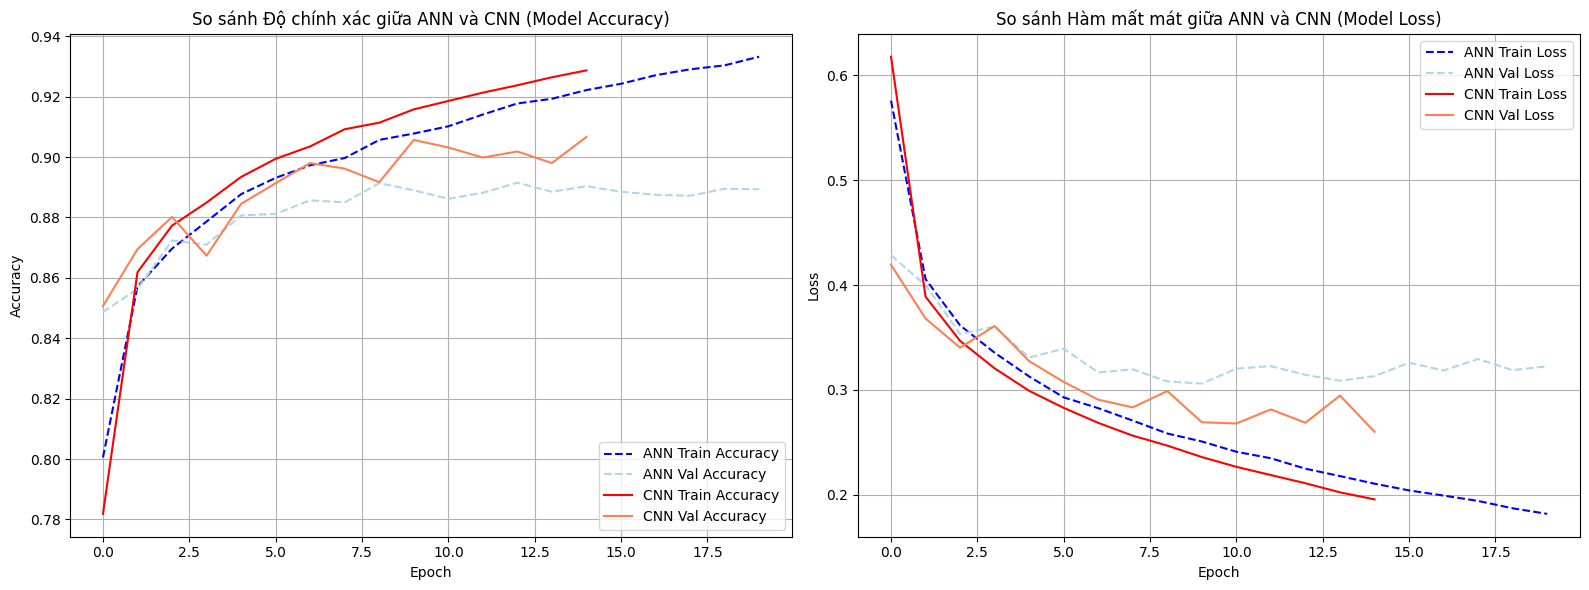


==================== KẾT QUẢ ĐÁNH GIÁ TỔNG KẾT TRÊN TẬP TEST ====================
[-] MÔ HÌNH 1 (ANN) -> Test Loss: 0.3338 | Test Accuracy: 89.10%
[-] MÔ HÌNH 2 (CNN) -> Test Loss: 0.2662 | Test Accuracy: 90.32%


In [4]:
# thiết lập vùng vẽ đồ thị gồm 2 cột (Cột 1: Accuracy, Cột 2: Loss)
plt.figure(figsize=(16, 6))

# --- BIỂU ĐỒ SO SÁNH ĐỘ CHÍNH XÁC (ACCURACY) ---
plt.subplot(1, 2, 1)
plt.plot(ann_fit.history['accuracy'], label='ANN Train Accuracy', linestyle='--', color='blue')
plt.plot(ann_fit.history['val_accuracy'], label='ANN Val Accuracy', linestyle='--', color='lightblue')
plt.plot(cnn_fit.history['accuracy'], label='CNN Train Accuracy', linestyle='-', color='red')
plt.plot(cnn_fit.history['val_accuracy'], label='CNN Val Accuracy', linestyle='-', color='coral')
plt.title('So sánh Độ chính xác giữa ANN và CNN (Model Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# --- BIỂU ĐỒ SO SÁNH HÀM MẤT MÁT (LOSS) ---
plt.subplot(1, 2, 2)
plt.plot(ann_fit.history['loss'], label='ANN Train Loss', linestyle='--', color='blue')
plt.plot(ann_fit.history['val_loss'], label='ANN Val Loss', linestyle='--', color='lightblue')
plt.plot(cnn_fit.history['loss'], label='CNN Train Loss', linestyle='-', color='red')
plt.plot(cnn_fit.history['val_loss'], label='CNN Val Loss', linestyle='-', color='coral')
plt.title('So sánh Hàm mất mát giữa ANN và CNN (Model Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

# --- ĐÁNH GIÁ TRÊN TẬP KIỂM THỬ THỰC TẾ (TEST DATASET) ---
print("\n" + "="*20 + " KẾT QUẢ ĐÁNH GIÁ TỔNG KẾT TRÊN TẬP TEST " + "="*20)
ann_score = fashion_model.evaluate(X_test_ann, y_test, verbose=0)
cnn_score = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)

print(f"[-] MÔ HÌNH 1 (ANN) -> Test Loss: {ann_score[0]:.4f} | Test Accuracy: {ann_score[1]*100:.2f}%")
print(f"[-] MÔ HÌNH 2 (CNN) -> Test Loss: {cnn_score[0]:.4f} | Test Accuracy: {cnn_score[1]*100:.2f}%")